**import required libraries**

In [ ]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')
import tensorflow as tf
from keras.preprocessing.image import load_img
from keras.models import Sequential, Model
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input
from keras.callbacks import LearningRateScheduler
from PIL import Image
from tensorflow.keras.utils import plot_model
from pathlib import Path
from tensorflow.keras.preprocessing.image import load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras.initializers import random_uniform, glorot_uniform, constant, identity
from tensorflow.keras.layers import Dropout, Input, Add, Dense, Activation, BatchNormalization, Flatten, Conv2D, MaxPooling2D, GlobalMaxPooling2D
from tensorflow.keras.models import Model, load_model
import warnings
warnings.filterwarnings("ignore", message=".*CuDNN.*")
warnings.filterwarnings("ignore", message=".*cuFFT.*")
warnings.filterwarnings("ignore", message=".*cuBLAS.*")
import os
from tensorflow.keras import utils
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import datasets, layers, models
from PIL import Image

**load the dataset**

In [3]:
# Dataset Path
# Current folder (Task 1)
CURRENT_DIR = os.getcwd()

# Go one level up to project root
BASE_DIR = os.path.dirname(CURRENT_DIR)

# Dataset folder in root
DATASET_PATH = os.path.join(BASE_DIR, "Datasets", "UTKFace")

BASE_DIRS = [DATASET_PATH]

print("Dataset Path:", DATASET_PATH)

Dataset Path: C:\Users\yuvra\AGE_GENDER_DETECTION\Datasets\UTKFace


In [4]:
# Read Dataset Images
image_paths = []
age_labels = []
gender_paths = []

for BASE_DIR in BASE_DIRS:

    for filename in tqdm(os.listdir(BASE_DIR)):

        temp = filename.split('_')

        if temp[0].isdigit():

            age = int(temp[0])
            gender = int(temp[1])

            image_path = os.path.join(BASE_DIR, filename)

            image_paths.append(image_path)
            age_labels.append(age)
            gender_paths.append(gender)


100%|████████████████████████████████████████████████████████████████████████| 23708/23708 [00:00<00:00, 131919.69it/s]


In [5]:
# Create DataFrame for easy data handling
df = pd.DataFrame()

df['image'] = image_paths
df['age'] = age_labels
df['gender'] = gender_paths

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (23708, 3)
                                               image  age  gender
0  C:\Users\yuvra\AGE_GENDER_DETECTION\Datasets\U...  100       0
1  C:\Users\yuvra\AGE_GENDER_DETECTION\Datasets\U...  100       0
2  C:\Users\yuvra\AGE_GENDER_DETECTION\Datasets\U...  100       1
3  C:\Users\yuvra\AGE_GENDER_DETECTION\Datasets\U...  100       1
4  C:\Users\yuvra\AGE_GENDER_DETECTION\Datasets\U...  100       1


In [6]:
# Gender dictionary for readable output
gender_dict = {0:'Male',1:'Female'}

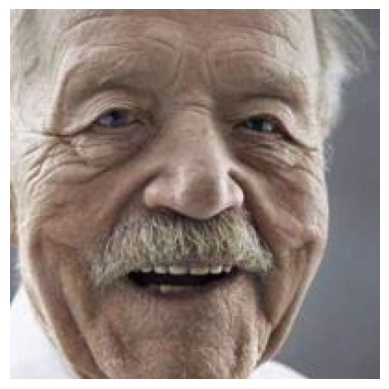

In [7]:
# Display sample image from dataset
img = Image.open(df['image'][0])
plt.axis('off')
plt.imshow(img)
plt.show()

**Visualize Age Distribution in Dataset**

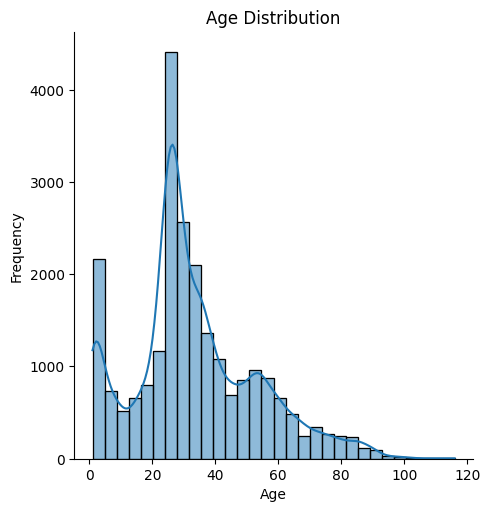

In [8]:
sns.displot(df['age'], kde=True, bins=30)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

**Feature Extraction Function**

In [9]:
def extract_feature(images):

    features = []

    for image in tqdm(images):

        img = Image.open(image).convert('L')
        
        # Convert images to grayscale and resize to 128x128
        img = img.resize((128,128), Image.BILINEAR)

        img = np.array(img)

        features.append(img)

    features = np.array(features)

    features = features.reshape(len(features),128,128,1)

    return features

In [10]:
X = extract_feature(df['image'])

print("X shape:", X.shape)

# Normalize pixel values
X = X / 255.0

100%|████████████████████████████████████████████████████████████████████████████| 23708/23708 [04:39<00:00, 84.76it/s]


X shape: (23708, 128, 128, 1)


In [11]:
# Labels
y_gender = np.array(df['gender'])
y_age = np.array(df['age'])

print("Gender label shape:", y_gender.shape)
print("Age label shape:", y_age.shape)

Gender label shape: (23708,)
Age label shape: (23708,)


**CNN Model Architecture**

In [12]:
input_shape = (128,128,1)

inputs = Input(input_shape)

conv1 = Conv2D(32,(3,3),activation='relu')(inputs)
maxp1 = MaxPooling2D((2,2))(conv1)

conv2 = Conv2D(64,(3,3),activation='relu')(maxp1)
maxp2 = MaxPooling2D((2,2))(conv2)

conv3 = Conv2D(128,(3,3),activation='relu')(maxp2)
maxp3 = MaxPooling2D((2,2))(conv3)

conv4 = Conv2D(256,(3,3),activation='relu')(maxp3)
maxp4 = MaxPooling2D((2,2))(conv4)

flatten = Flatten()(maxp4)

dense1 = Dense(256,activation='relu')(flatten)
dense2 = Dense(256,activation='relu')(flatten)

dropout1 = Dropout(0.3)(dense1)
dropout2 = Dropout(0.3)(dense2)

# Gender Output
output1 = Dense(1,activation='sigmoid',name='gender_out')(dropout1)

# Age Output
output2 = Dense(1,activation='relu',name='age_out')(dropout2)

model = Model(inputs=inputs,outputs=[output1,output2])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 126, 126, 32)      │             320 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 63, 63, 32)        │               0 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 61, 61, 64)        │          18,496 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 30, 30, 64)        │               0 │ conv2d_1[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 28, 28, 128)       │          73,856 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 14, 14, 128)       │               0 │ conv2d_2[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 12, 12, 256)       │         295,168 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_3               │ (None, 6, 6, 256)         │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 9216)              │               0 │ max_pooling2d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 256)               │       2,359,552 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 256)               │       2,359,552 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 256)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 256)               │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gender_out (Dense)            │ (None, 1)                 │             257 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ age_out (Dense)               │ (None, 1)                 │             25

 Total params: 5,107,458 (19.48 MB)

 Trainable params: 5,107,458 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

**Train Test Split**

In [13]:
y_combined = np.column_stack((y_gender,y_age))

X_train,X_temp,y_train_combined,y_temp_combined = train_test_split(
    X,y_combined,test_size=0.2,random_state=42
)

X_test,X_val,y_test_combined,y_val_combined = train_test_split(
    X_temp,y_temp_combined,test_size=0.5,random_state=42
)

y_train_gender,y_train_age = y_train_combined[:,0],y_train_combined[:,1]
y_test_gender,y_test_age = y_test_combined[:,0],y_test_combined[:,1]
y_val_gender,y_val_age = y_val_combined[:,0],y_val_combined[:,1]

In [14]:
# Training Configuration
model_path = './best_model.keras'

checkpointer = ModelCheckpoint(
    filepath=model_path,
    monitor='val_gender_out_accuracy',
    verbose=1,
    mode='max',
    save_best_only=True
)

model.compile(
    loss=['binary_crossentropy','mae'],
    optimizer='adam',
    metrics=['accuracy','mae']
)

annealer = LearningRateScheduler(lambda x:1e-3*0.9**x)

**Train model**

In [15]:
history = model.fit(
    x=X_train,
    y=[y_train_gender, y_train_age],
    batch_size=128,
    epochs=30,
    validation_data=(X_val,[y_val_gender, y_val_age]),
    callbacks=[annealer, checkpointer]
)

Epoch 1/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - age_out_loss: 17.7780 - age_out_mae: 17.7781 - gender_out_accuracy: 0.5284 - gender_out_loss: 0.7448 - loss: 18.5230
Epoch 1: val_gender_out_accuracy improved from None to 0.52256, saving model to ./best_model.keras

Epoch 1: finished saving model to ./best_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - age_out_loss: 16.0370 - age_out_mae: 16.0545 - gender_out_accuracy: 0.5286 - gender_out_loss: 0.7095 - loss: 16.7641 - val_age_out_loss: 14.4421 - val_age_out_mae: 14.3694 - val_gender_out_accuracy: 0.5226 - val_gender_out_loss: 0.6885 - val_loss: 15.0579 - learning_rate: 0.0010
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - age_out_loss: 14.5226 - age_out_mae: 14.5227 - gender_out_accuracy: 0.5613 - gender_out_loss: 0.6775 - loss: 15.2002
Epoch 2: val_gender_out_accuracy improved from 0.52256 to 0.73513, saving model to ./best_model.keras

Epoch 2: finished saving model to ./best_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━

**Plot Accuracy**

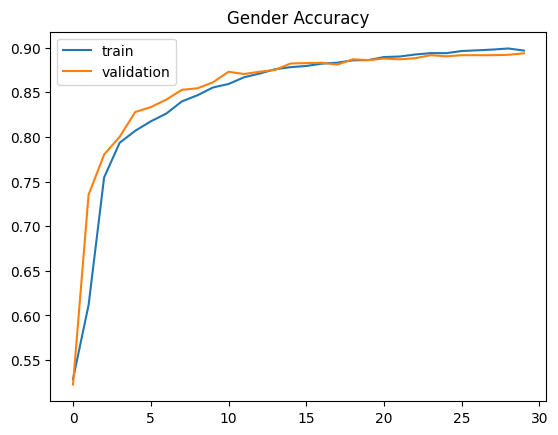

In [16]:
plt.plot(history.history['gender_out_accuracy'])
plt.plot(history.history['val_gender_out_accuracy'])

plt.title('Gender Accuracy')
plt.legend(['train','validation'])

plt.show()

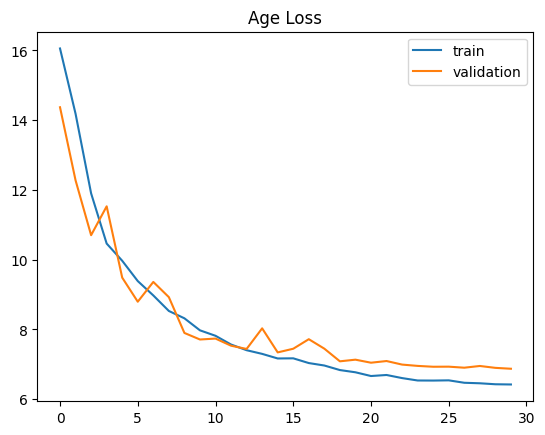

In [17]:
plt.plot(history.history['age_out_mae'])
plt.plot(history.history['val_age_out_mae'])

plt.title('Age Loss')
plt.legend(['train','validation'])

plt.show()

**Hair Detection Logic**

In [18]:
def detect_hair_type(image):

    hair_region = image[0:40,:]

    avg_intensity = np.mean(hair_region)

    if avg_intensity < 0.45:
        return "Long"
    else:
        return "Short"

Original Gender: Male
Original Age: 21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
Predicted Gender: Male
Predicted Age: 24
Hair Type: Short


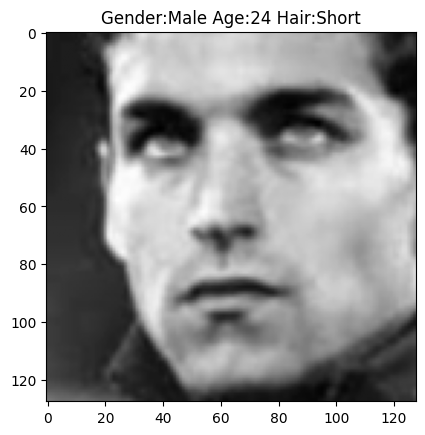

In [19]:
# Example Prediction
image_index = 3000

print("Original Gender:", gender_dict[y_gender[image_index]])
print("Original Age:", y_age[image_index])


pred = model.predict(X[image_index].reshape(1,128,128,1))

pred_gender = gender_dict[int(round(pred[0][0][0]))]
pred_age = round(pred[1][0][0])


hair_type = detect_hair_type(X[image_index].reshape(128,128))


if 20 <= pred_age <= 30:

    if hair_type == "Long":
        pred_gender = "Female"
    else:
        pred_gender = "Male"


print("Predicted Gender:", pred_gender)
print("Predicted Age:", pred_age)
print("Hair Type:", hair_type)


plt.title(f'Gender:{pred_gender} Age:{pred_age} Hair:{hair_type}')
plt.imshow(X[image_index].reshape(128,128), cmap='gray')
plt.show()

**Save the model**

In [25]:
# Current directory (Task 1)
CURRENT_DIR = os.getcwd()

# Go one level up → project root
PROJECT_ROOT = os.path.dirname(CURRENT_DIR)

# models folder in project root
models_dir = os.path.join(PROJECT_ROOT, "models")

# Create models folder if not exists
os.makedirs(models_dir, exist_ok=True)

# Final model path
model_path = os.path.join(models_dir, "Age_Sex_Detection.h5")

# Save model
model.save(model_path)

print("Model saved at:", model_path)

Model saved at: C:\Users\yuvra\AGE_GENDER_DETECTION\models\Age_Sex_Detection.h5
